In [ ]:
!pip install import_ipynb
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/МИФИ Машинное обучение/Классическое машинное обучение/')

import import_ipynb
import regression_pipeline as pipelines

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
result = pipelines.run_regression_task(pipelines.RegressionTask(name="CC50", target_column="log_CC50, mM"), True)

'start task CC50'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'fit model :Ridge'

{'task': 'CC50',
 'model': 'Ridge',
 'cv_r2_mean': 0.30254306219279936,
 'test_mae': 0.4462880068215272,
 'test_rmse': np.float64(0.6062889398997887),
 'test_r2': 0.24496666890436736,
 'best_params': '{"model__alpha": 0.01, "selector__k": 50}'}

'fit model :Lasso'

...

{'task': 'CC50',
 'model': 'RandomForest',
 'cv_r2_mean': 0.4028917411848572,
 'test_mae': 0.4013277931266445,
 'test_rmse': np.float64(0.54262795392598),
 'test_r2': 0.3952008688528442,
 'best_params': '{"selector__k": 50, "model__n_estimators": 200, "model__min_samples_split": 5, "model__min_samples_leaf": 1, "model__max_features": "sqrt", "model__max_depth": 10}'}

'fit model :GradientBoosting'

{'task': 'CC50',
 'model': 'GradientBoosting',
 'cv_r2_mean': 0.39537658720700575,
 'test_mae': 0.3926416634224502,
 'test_rmse': np.float64(0.5546172399223821),
 'test_r2': 0.36817971813551764,
 'best_params': '{"selector__k": 50, "model__subsample": 0.7, "model__n_estimators": 500, "model__min_samples_split": 10, "model__min_samples_leaf": 4, "model__max_depth": 5, "model__learning_rate": 0.02}'}

'fit model :XGBoost'

{'task': 'CC50',
 'model': 'XGBoost',
 'cv_r2_mean': 0.4031449722162364,
 'test_mae': 0.3928631492926079,
 'test_rmse': np.float64(0.5513760991624264),
 'test_r2': 0.3755427594340436,
 'best_params': '{"selector__k": 25, "model__subsample": 0.7, "model__n_estimators": 100, "model__max_depth": 7, "model__learning_rate": 0.05}'}

Выводы по задаче регрессии: CC50 (Цитотоксичность)

Для решения задачи прогнозирования концентрации полумаксимального цитотоксического действия (CC50​) был использован тот же пайплайн что и для IC50, те при исследовании был автоматизированный подбор гиперпараметров и сравнение различных семейств алгоритмов (линейные модели и древесные ансамбли).
Основные результаты:

1. Линейные модели: Как и в предыдущих экспериментах, модели Lasso, Ridge и ElasticNet продемонстрировали крайне низкую эффективность. Отрицательные или близкие к нулю значения коэффициента детерминации указывают на то, что линейные зависимости не способны описать механизмы токсического действия соединений на клетки. Это подтверждает высокую сложность и нелинейность биохимического взаимодействия, как и ожидалось.

2. Ансамблевые модели: Наилучшую предсказательную способность показал алгоритм RandomForest. Использование подбора гиперпараметров позволило достичь $R^2$=0.395 на тестовой выборке.

Модель демонстрирует высокую стабильность: показатели на кросс-валидации (0.403) и на отложенном тесте практически идентичны, что говорит об отличной обобщающей способности и отсутствии переобучения. Хотя итоговый коэффициент детерминации ниже, чем в задаче IC50​, модель успешно объясняет около 40% всей дисперсии данных.

Модели XGBoost и GradientBoosting показали результаты, близкие к лидеру, однако чуть больше склонялись к использованию меньшего числа признаков (k=25 против k=50 у RF), что может говорить о наличии шума в части дескрипторов.

| Модель | $R^2$ (Test) | CV $R^2$ (mean) | MAE | RMSE | Лучшие параметры |
| :--- | :---: | :---: | :---: | :---: | :--- |
| **RandomForest** | **0.3952** | 0.4029 | 0.4013 | 0.5426 | k: 50, n_est: 200, depth: 10, split: 5 |
| **XGBoost** | **0.3755** | 0.4031 | 0.3929 | 0.5514 | k: 25, n_est: 100, depth: 7, sub: 0.7 |
| **GradientBoosting** | **0.3682** | 0.3954 | 0.3926 | 0.5546 | k: 50, n_est: 100, depth: 4, lr: 0.05 |
| **Lasso** | **-0.0075** | 0.2862 | 0.5147 | 0.7001 | k: 50, alpha: 0.001 |
| **ElasticNet** | **-0.0101** | 0.2858 | 0.5160 | 0.7010 | k: 50, alpha: 0.001, l1_ratio: 0.2 |
| **Ridge** | **-0.0336** | 0.2868 | 0.5250 | 0.7091 | k: 50, alpha: 0.1 |

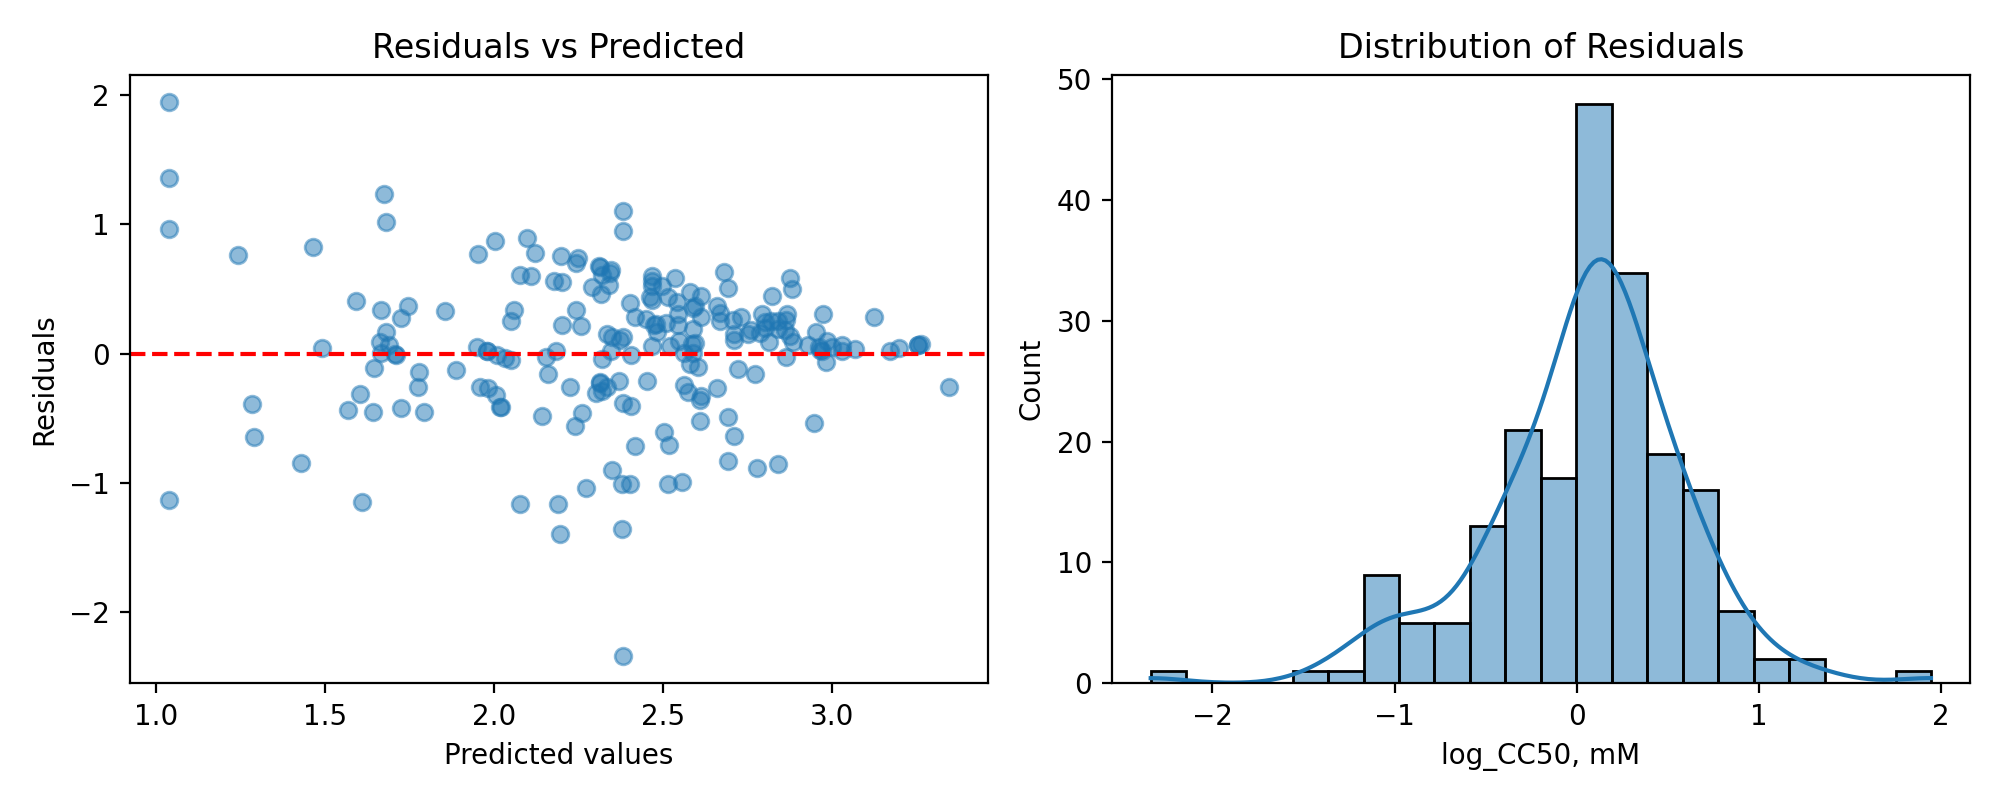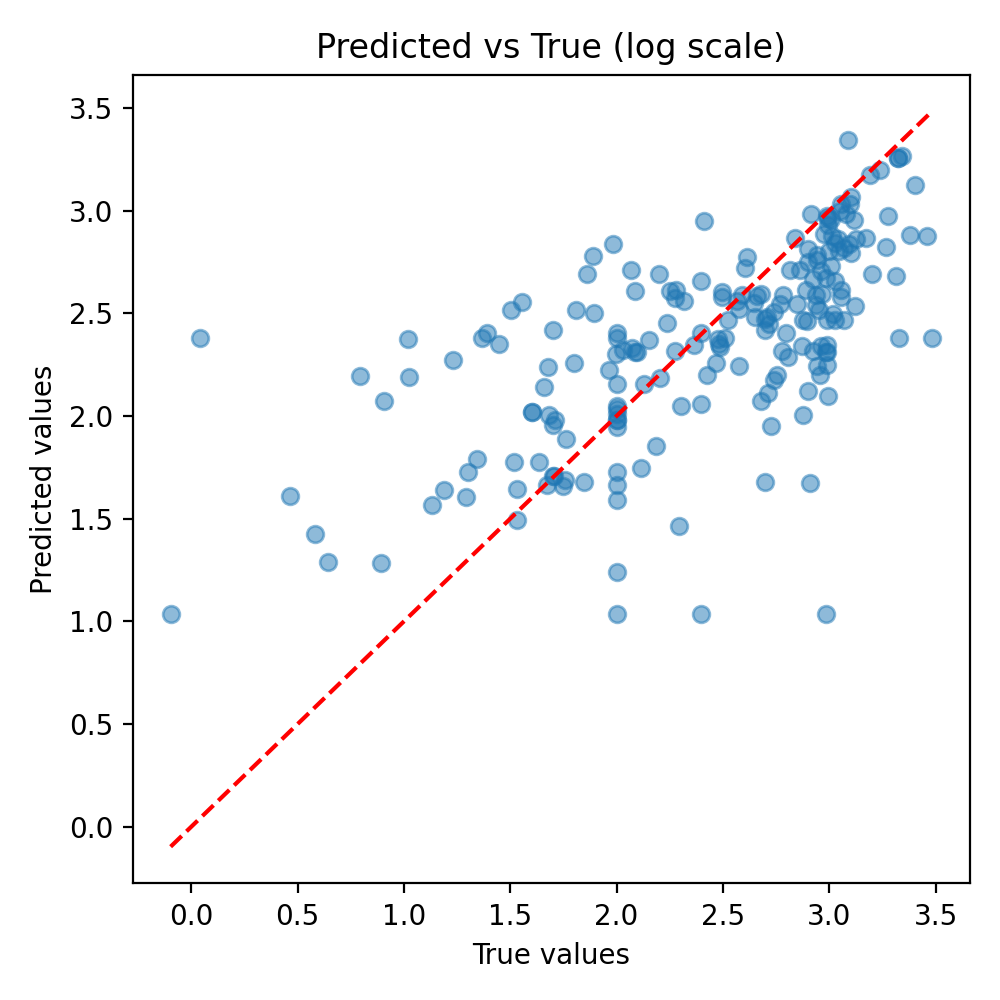

Рекомендации по улучшению:

1. Несмотря на использование логарифмированного таргета, на Residuals сохраняется веерная структура. Это указывает на то, что текущий набор дескрипторов теряет эффективность для сильнотоксичных соединений. Возможно стоит измененить набора дескрипторов с помощью консультация специалиста в данной области

2. На графике Predicted vs True заметно, что модель систематически занижает значения для наиболее токсичных соединений. Это может быть связано с дисбалансом выборки (недостатком примеров веществ с экстремально высокой цитотоксичностью). Рекомендуется применение техник перевзвешивания объектов (Sample Weighting) при обучении.

3. Необходимо провести химический аудит молекул с максимальной ошибкой. Если они принадлежат к одному структурному классу, имеет смысл выделить их в отдельную подзадачу.